
## 1. Introduction

### 1.1 Overview of the Topic

Urban environments are shaped by multiple factors, including economic trends, demographic changes, and urban planning. Low-Traffic Neighbourhoods (LTNs) have become a prominent urban intervention, particularly in cities like London. LTNs aim to reduce vehicular traffic and improve pedestrian safety, while also enhancing overall urban livability. Simultaneously, there has been an increase in certain retail establishments—such as sourdough bakeries, craft breweries, boutique shops—within these neighbourhoods. This study examines the relationship between LTNs and the rise of such retail, analysing whether traffic interventions act as catalysts for urban renewal and gentrification.

### 1.2 Relevant Research and Current Trends

Studies have explored the impact of LTNs on urban dynamics. @aldred2021 conducted a spatial analysis of London’s LTNs, finding that these interventions not only reduce traffic but also improve neighbourhood aesthetics and social engagement. @carpio2024 discussed the role of symbolic capital in urban commercial spaces, showing how high-status amenities can drive socio-economic changes. Research by @Barajas2017 and @butler2006 introduced the concept of super-gentrification, where affluent residents and businesses increase property values, often displacing lower-income residents.

The rise of artisanal retail in pedestrian-friendly areas supports these findings, indicating a link between urban planning and commercial evolution. Big data methodologies, as applied by  @feizizadeh2024, provide a more granular analysis of retail distribution patterns, revealing insights into consumer behaviour and urban economic health.

In this study, **symbolic capital (SymCap Retail)** refers to retail establishments that serve as social hubs, such as cafes and boutique shops. These businesses contribute to placemaking, transforming urban spaces into cultural and economic centres. This interaction between LTNs and SymCap Retail will be analysed to determine how traffic interventions influence the retail landscape and social fabric of neighbourhoods.

### 1.3 Research Objectives and Key Findings

The primary objective of this research is to investigate whether LTNs create environments conducive to this kind of retail (henceforth, *SymCap Retail*), indirectly driving neighbourhood transformation. Specifically, it aims to analyse the spatial distribution of SymCap Retail in relation to LTNs in London. An alternative hypothesis considers demand density as a stronger predictor of retail distribution.

Initial findings suggest that while both LTNs and SymCap Retail have grown since 2020, there is no significant clustering of these businesses within LTNs. This is likely because LTNs are mostly residential areas. However, a correlation between LTNs and the broader spread of SymCap Retail is observed, though it is not directly causal. Spatial analysis, such as Voronoi plots, will help explore how factors like demand density influence retail patterns, offering valuable insights into urban planning.

### 1.4 Research Questions

The primary research question is:

1. Do LTNs contribute to urban renewal by attracting SymCap Retail establishments? []{#Q-1}

Supporting questions:

2. How do LTNs affect the spatial distribution of SymCap Retail in London? []{#Q-2}
3. What alternative factors, such as demand density, better explain the distribution of SymCap Retail across London? []{#Q-3}


### 1.5 Data Sources and Evaluation

This study utilises multiple datasets to conduct a comprehensive spatial and economic analysis:

1. Retail and Traffic Data:
   - OSMnx Python Package [@boeing2024]: This graph representation of the road network utilised to study the relationship between SymCap Retail businesses and LTNs in London across the road network. 
   - Low-Traffic Neighbourhoods Dataset [@aldred2021]: Sourced from the Westminster University project repository, this dataset includes detailed maps and descriptions of LTNs introduced in London between March 2020 and November 2022. It covers modal filters and LTN area boundaries, essential for correlating retail activity with LTN locations.

2. Business Data:
   - Companies House Data Product [@companieshouse2024]: this dataset provides basic information on live companies registered in the UK. It is essential for identifying active SymCap retail establishments. While Carpio et al. [@carpio2024] utilise the Foursquare API to capture socio-symbolic dimensions, this project avoids the use of APIs to enhance reproducibility, relying instead on directly sourced business data.

3. Demographic and Income Data:
   - Population Density Data (@gla2024): this dataset offers comprehensive data on land area and population density across London wards and boroughs, from 2001 to 2050. GLA estimates are included, allowing for nuanced demographic analysis.
   - Income and Tax Data [@ukincome2024]: this dataset provides detailed borough-level income and tax information, contributing to an analysis of economic factors influencing retail distribution.

4. Geographical Features:
   - London Administrative Boundaries: Sourced from [@culic2014], this GeoJSON file outlines the administrative boundaries of London boroughs, supporting spatial analysis and mapping within the study.
   - Additional geographical data includes features like the Thames River [retrieved from @osm2024], enabling enhanced visualisation of the urban layout.
  

---


## 2. Data Overview and Preprocessing

### 2.1 Importing Libraries

In [1]:
# Internal libraries
import json, os, glob
from textwrap import wrap
from IPython.display import display

# Basic external libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Plotting libraries
import seaborn as sns
import colorcet as cc

# Graph libraries
import osmnx as ox
import networkx as nx

# Geo libraries
import geopandas as gpd
from shapely.geometry import Polygon, Point, box

# Advanced libraries
from scipy.stats import gaussian_kde
from scipy.spatial import Voronoi

# Set notebook style and parameters
plt.rcParams['text.usetex'] = True
sns.set_theme('notebook', 
            style='dark', 
            rc={'figure.figsize':(10,6)})  # default is (6.4, 4.8)


# For progress bars
from tqdm import tqdm
tqdm.pandas()

# For cleaner printing
import warnings
warnings.simplefilter(action='ignore')

# Older verions of Jupyter require this line
# %matplotlib_inline

### 2.2 SymCap Retail in London

#### 2.2.1 Data Overview

Dealing with various data types and pre-processing the data is a crucial step to ensure that the analysis yields reliable and meaningful insights. In this case, we are working with a large dataset that contains basic information about live companies registered in the UK. 

For this project, we will focus on a specific subset of the data - companies located in London. We will be investigating the following variables:

- `CompanyName`: The registered name of the company.
- **`RegAddress.AddressLine1` & `RegAddress.AddressLine2`**: The address lines of the company's registered office.
- **`RegAddress.PostTown`**: The town or city where the company is registered.
- **`RegAddress.PostCode`**: The postcode of the business.
- **`IncorporationDate`**: The date the company was incorporated.

These variables will be used to filter and analyse the companies, particularly those in inner London, and further refine a subset of interest.

#### 2.2.2 Pre-processing

In this first crucial step, the dataset must be cleaned and pre-processed. We start by loading a preselection (`BasicCompanyDataAsOneFile_excerpt.csv`) due to its large size. The full dataset is approximately 2.7 GiB when unzipped and contains data on over 5.6 million businesses. 

We focus on companies within inner London, using the `RegAddress.PostTown` data in the dataset. Next, we use a regular expression to extract a range of keywords. This includes words like "Coffee," "Brewery," and "Craft". As explained above, the presence of these keywords serves as a proxy for symbolic capital in these retail businesses. This classification of is then added as an extra feature to the dataset as the variable `retail_type`.

We then perform a geocoding to convert the addresses of retail businesses into geographic coordinates. For information on geocoding we consulted and followed guidance from [Geopy](https://geopy.readthedocs.io/en/stable/#usage-with-pandas), [Geopandas](https://geopandas.org/en/stable/docs/user_guide/geocoding.html), [Photon](https://photon.komoot.io/) and [Google Maps](https://developers.google.com/maps/documentation/geocoding/overview).^[Note that we are loading a preprocessed excerpt to avoid unnecessary API calls.]

In [5]:
CompanyData = pd.read_csv('.data/BasicCompanyDataAsOneFile_excerpt.csv')

In [6]:
def london_CompanyData(
        CompanyData: pd.DataFrame) -> pd.DataFrame:

    longlist_of_postcodes = ['EC1A', 'EC1M', 'EC1N', 'EC1P', 'EC1R', 'EC1V', 'EC1Y','EC2A', 'EC2M', 'EC2N', 'EC2P', 'EC2R', 'EC2V', 'EC2Y', 'EC3A', 'EC3M', 'EC3N', 'EC3P', 'EC3R', 'EC3V','EC4A', 'EC4M', 'EC4N', 'EC4P', 'EC4R', 'EC4V', 'EC4Y','WC1A', 'WC1B', 'WC1E', 'WC1H', 'WC1N', 'WC1R', 'WC1V', 'WC1X','WC2A', 'WC2B', 'WC2E', 'WC2H', 'WC2N', 'WC2R','W1A', 'W1B', 'W1C', 'W1D', 'W1F', 'W1G', 'W1H', 'W1J', 'W1K', 'W1S', 'W1T', 'W1U', 'W1W','E1', 'E1W','N1', 'N1C', 'N1P', 'NW1', 'NW1W','SE1', 'SE11','SW1A', 'SW1E', 'SW1H', 'SW1P', 'SW1V', 'SW1W', 'SW1X', 'SW1Y']

    # We drop rows where `RegAddress.PostCode` is missing
    london_companies = CompanyData.dropna(subset="RegAddress.PostCode")

    # We filter the dataset to only include businesses whose postcodes start with prefixes associated with inner London. 
    # This gives us a smaller, more relevant subset of the data to work with.
    inner_london_companies = london_companies[
        london_companies["RegAddress.PostCode"
                         ].str.startswith(tuple(longlist_of_postcodes))]

    # Rename columns to remove whitespace
    bus_in_lon = inner_london_companies.rename(columns={
        col: col.strip() for col in inner_london_companies.columns
        })
    
    assert bus_in_lon.CompanyNumber.is_unique

    bus_in_lon = bus_in_lon.set_index('CompanyNumber')

    # Convert to datetime
    bus_in_lon.IncorporationDate = pd.to_datetime(bus_in_lon.IncorporationDate)

    bus_in_lon = bus_in_lon[['CompanyName', 
                             'RegAddress.AddressLine1', 
                             'RegAddress.AddressLine2', 
                             'RegAddress.PostTown', 
                             'RegAddress.PostCode', 
                             'IncorporationDate']]

    print("We now have:", inner_london_companies.shape[0], "businesses.") # 758,338

    return inner_london_companies


REGEX=r'(SOURDOUGH|BREWERY|ARTISAN|\
BARISTA|CRAFT|GOURMET|BOUTIQUE|DELICATESSEN|\
    CHEESE|BAKERY|COFFEE|COCKTAIL)' 

def hi_end_retail(
        london_companies: pd.DataFrame, 
        regex: str) -> pd.DataFrame:
    
    mask = london_companies['CompanyName']\
        .str.contains(regex, case=False, regex=True)

    sym_retail = london_companies[mask].copy()

    sym_retail['retail_type'] = london_companies['CompanyName']\
        .str.extract(regex).astype('category')

    sym_retail['Address'] = sym_retail['RegAddress.AddressLine1'] + \
    ', ' + sym_retail['RegAddress.PostCode'] + ', Greater London, UK'

    print("We now have:", sym_retail.shape[0], "businesses.") # 1,690 

    return sym_retail


In [7]:
def geocode(row):
    """
    Geocodes the address. 
    
    :Note: 
        This uses Geopy with Google Maps. This is free but requires an API key.
        The default uses `nominatim <https://geopy.readthedocs.io/en/stable/#nominatim>`_.
        Geocoding services may fail to return coordinates for certain addresses. 
        In such cases, we log the issue and move on to the next address. 
    """
    from geopy.geocoders import GoogleV3
    from geopy.extra.rate_limiter import RateLimiter
    geolocator = GoogleV3(api_key=os.getenv('GOOGLE_API_KEY')) 
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)
    try:        
        location = geocode(query=row['Address']) 
        if location:            
            return Point(location.longitude, location.latitude)
        else:
            print('Coordinates not found:', row['Address'])
            return None
        
    except Exception as e:
        print(f"Issue at: {row['Address']} - Error: {e}")
        return None

In [ ]:
# To run
london_companies = london_CompanyData(CompanyData)

In [9]:
# To run geocoding API (already included in `london_companies`)

# hi_end_retail_df = hi_end_retail(london_companies, regex=REGEX)
# hi_end_retail_df['geometry'] = hi_end_retail_df.apply(geocode, axis=1)
# hi_end_retail_gdf = gpd.GeoDataFrame(hi_end_retail_df)

### 2.3 Ward and Borough-level data on Income and Population 

#### 2.3.1 Income Data

The income data covers multiple years, and where missing, we have supplemented the dataset using city-level estimates. This is a common approach in data imputation, allowing us to fill gaps without making drastic assumptions that might distort the overall analysis.

##### Key Pre-processing Steps:

1. Combining data structures: The income data comes from various sources, including Excel and OpenDocument formats. It spans from 2010 to 2022, but the structure of these files differs year by year. Therefore, different methods are applied to process the early data (2010-2017), borough-level data (2018-2022), and more recent data (2019-2022).

2. Handling mssing data: Where income data for specific wards or years is missing, we rely on city-level averages. This approach is reasonable for large datasets and helps maintain continuity in analysis without introducing too much bias.

3. Population Density: For population density, we filled missing ward-level data using borough-level information, especially for wards whose boundaries were redrawn. This ensures consistency in the dataset, although it introduces some approximations.

In [10]:
DATA = r".data/income_data/"

early_data_files = ['table3-13.xls',        # 10-11
                'table3-13-12.xls',         # 11-12        
                'Table_3_13_13.xls',        # 12-13
                'Table_3_13_14.xlsx',       # 13-14
                'NS_Table_3_13_1415.xlsx',  # 14-15
                'NS_Table_3_13_1516.xlsx',  # 15-16
                'NS_Table_3_13_1617.xlsx']  # 16-17

# Read data files, formatted differently
data_file_1718 = 'NS_Table_3_13_1718.xlsx'  # 17-18
data_file_1819 = 'NS_Table_3_14a_1819.ods'  # 18-19

# Read recent data files, formatted differently
recent_data_files = glob.glob(DATA + 'Table*.ods')      # 19-20
                                                        # 20-21
                                                        # 21-22

# Read city-level excel files with columns 'A,T,U' 
def process_10_17(df: pd.DataFrame) -> pd.Series:
    df = df.dropna(subset=df.columns[0])
    df = df.set_index(df.columns[0])
    return df[df.index.str.contains("London")]

def concat_10_17() -> pd.DataFrame:
    dfs = [pd.read_excel(DATA + o, usecols='A,T,U') 
           for o in early_data_files] 
    dfs += [pd.read_excel(DATA + data_file_1718, usecols='B,U,V')]
    avg_income_over_time = [process_10_17(df) for df in dfs]
    yrs = ['10-11', '11-12', '12-13', 
           '13-14', '14-15', '15-16', 
           '16-17', '17-18']
    return pd.concat(avg_income_over_time, axis=1, keys=yrs*2)

# Read borough-level data for 2019 to 2022
def mean_19_22(path) -> pd.Series:    
    df = pd.read_excel(path, sheet_name=2, skiprows=4)
    df = df.set_index(df.columns[0])    
    df = df.loc["E09000002":"E09000033"]
    df = df.set_index('Area Name')
    return df.loc[:, 'Total income: Mean (Central Estimate)'] 

def median_19_22(path) -> pd.Series:    
    df = pd.read_excel(path, sheet_name=3, skiprows=4)
    df = df.set_index(df.columns[0])    
    df = df.loc["E09000002":"E09000033"]
    df = df.set_index('Area Name')
    return df.loc[:, 'Total income: Median (Central Estimate)'] 

def concat_19_20() -> pd.DataFrame:
    df_list = [
        pd.concat([mean_19_22(path), median_19_22(path)], axis=1) 
        for path in recent_data_files]

    yrs = ['19-20', '20-21', '21-22']
    return pd.concat(df_list, axis=1, keys=yrs*2)  
    
# Read borough-level data for 2018 to 2019, again formatted differently
def process_18_19(df_19_22) -> pd.DataFrame:
    df = pd.read_excel(DATA + data_file_1819, 
                       sheet_name=1, usecols='A,AS,AW')
    df = df.dropna(subset=df.columns[0])
    df = df.set_index(df.columns[0])
    df = df.loc["E09000002":"E09000033"]
    df['Area Name'] = df_19_22.index
    return df.set_index('Area Name') 

In [11]:
# Process all
df_10_16 = concat_10_17()
df_19_22 = concat_19_20()
df_18_19 = process_18_19(df_19_22)

# Broadcast income values for early years across boroughs
df_10_16_bcd = pd.concat([df_10_16] * len(df_19_22), ignore_index=True)
df_10_16_bcd.index = df_19_22.index

# Final df
income_df = pd.concat([df_10_16_bcd, df_18_19, df_19_22], axis=1)

# Create period_range multi index 
tuples_for_index = [(date, c) 
                    for date in pd.period_range('2010Q1', 
                                                '2021Q4', 
                                                freq='Y-APR') 
                    for c in ['mean', 'median']
                    ]

income_df.columns = pd.MultiIndex.from_tuples(tuples_for_index, 
                                              names=['period', 'measure'])

#### 2.3.2 Geospatial Data and Demographics

Geospatial data is a critical component in this project, particularly for analysing population density at the borough and ward levels in London. In this preprocessing step, the geographic data (administrative boundaries) is joined with demographic data (population density and income).

To calculate population density accurately, we combine demographic and geographic data. The process involves two main steps. We start by assigning wards-level population density data to geographic wards. This is accomplished by performing a join operation that connects borough names and codes in the dataset with their corresponding geographic areas. For wards with missing population density information (e.g., when ward boundaries have been redrawn), we subsequently fill in the gaps by using the borough-level data. This two-step approach ensures that each ward has population density data, even if direct ward-level data is unavailable. 

Once population density has been processed, we calculate the `demand_density` by multiplying the income data by the population density for each time period. This is done across multiple columns, resulting in a new measure that helps analyse the population and income interaction over time. Our formula is this:
$$
Demand \ Density = Income \times Population \ Density
$$
Together this gives us a combined measure of $Income / Km^2$ which we will discuss in more detail in the analysis.

In [12]:
def load_demographics() -> pd.DataFrame:
    # Add inner and outer columns for easy filtering, as well as Area name for better joining
    population_density_bor = pd.\
        read_excel(r".data/land-area-population-density-london.xlsx",
                                           sheet_name=1, 
                                           skiprows=1)
    
    return population_density_bor.dropna(subset=['Area name', 
                                                 'Inner/ Outer London'])


# Process geo files
def process_density(income_df: pd.DataFrame) -> gpd.geodataframe:
    # Read wards 
    wards = gpd.read_file(
        r".data\London-wards-2018\London_Ward_CityMerged.shp")

    population_density_bor = load_demographics()

    # First a left join on all the boroughs (here 'districts')
    wards_w_io = wards.reset_index().set_index('LAGSSCODE')\
        .join(population_density_bor\
              .set_index('Code')['Inner/ Outer London'])

    # Outer join on the area code to add a first layer of population data
    wards_w_b_pop = wards_w_io\
        .reset_index().set_index('LAGSSCODE')\
        .join(population_density_bor\
            .set_index('Code')[[
                'Area name',
                'Population per square kilometre']
                ], how='outer')

    # Reads ward-level population density
    population_density_ward = pd.read_excel(
        r".data/land-area-population-density-london.xlsx", 
        sheet_name=2, skiprows=1)

    population_density_ward = population_density_ward[
        ['Codes', 'Population per square kilometre']]\
            .set_index('Codes')

    wards_w_b_pop['population'] = wards_w_b_pop['Population per square kilometre']

    # Use borough-level data to fill gaps in ward-level data
    wards_w_b_pop['population_filled'] = wards_w_b_pop.population\
        .fillna(population_density_ward['Population per square kilometre'])

    # Join with income data
    ward_demand = wards_w_b_pop.set_index('Area name')\
        .join(income_df.xs('median', level=1, axis=1))
    
    # Create labels for demand density
    period_cols = ward_demand.loc[:,pd.Period('2010', 'Y-APR'):
                                  pd.Period('2021', 'Y-APR')].columns
    
    col_labels = [f"dd_{col}-{period_cols[i]+1}" 
                  for i, col in enumerate(period_cols)]

    # Calculate demand density and add column
    for col, label in zip(period_cols, col_labels):
        ward_demand[label] = ward_demand[col] * ward_demand.population_filled
        
    return ward_demand

In [13]:
london_demand_density = process_density(income_df)

#### 2.3.3 Other geo features

To enhance the recognisability of London in our spatial analysis, we add two defining geographic features: the **River Thames** and the administrative boundaries of London boroughs. The River Thames is a central feature in London, and including its geographic outline in our maps provides context and orientation for spatial data. The river is loaded from a shapefile and transformed to the correct coordinate system (`EPSG:32630`). The boundaries of London’s boroughs are also included, using a GeoJSON file. These boundaries are a useful visual marker for our subsequent analysis.

In [14]:
def geo_river() -> gpd.geodataframe:
    river = gpd.read_file(".data/gis_osm_waterways_free_1.shx")
    return river[river.name == 'River Thames'].to_crs(32630)


def read_admin_boundaries() -> gpd.geodataframe:
    london = gpd.read_file(r".data/london_boroughs.geojson")\
        .to_crs(epsg=32630) 
    london = london.set_index('name')    
    demographics = load_demographics()
    return london\
        .join(demographics.set_index('Area name')['Inner/ Outer London'])

river = geo_river()
london = read_admin_boundaries()

### 2.4 Traffic calming measures

In addition to geographic features, we analyse *traffic calming measures* and *Low-Traffic Neighbourhoods* (LTNs). We load two datasets: traffic calming filters, and LTN areas. Both datasets are transformed to the same projection. We exclude any measures that have been removed, ensuring our analysis focuses only on active features.

In [15]:
def read_ltns() -> gpd.geodataframe:
    traffic_calming = gpd.read_file(
        r'.data/LTN_filters_Nov_22_share.geojson').to_crs(epsg=32630)
    mask = traffic_calming.Date_Remov.notna()
    traffic_calming = traffic_calming[~mask]
    print(f"Note that {mask.sum()} traffic calming measures were removed.")

    ltn = gpd.read_file(r'.data/LTN_areas_Nov_22_share.geojson')\
        .to_crs(epsg=32630)

    mask = ltn.Date_Remov.notna()
    ltn = ltn[~mask]
    print(f"Note that {mask.sum()} ltns were removed.")
    return traffic_calming, ltn

traffic_calming, ltn = read_ltns()

Note that 104 traffic calming measures were removed.
Note that 19 ltns were removed.


### 2.5 Road Features

In this section, we incorporate road network data into the analysis. The road features in London are extracted from OpenStreetMap data via the OSMNX package and processed for further spatial analysis. For visualisation purposes, we filter on different road types, such as trunk, primary, secondary, and tertiary roads, which are essential for visual representation and communicability of the results.

The road network is extracted by defining a polygon that outlines the geographic area of interest (in this case, Inner London). Using this boundary, the package queries the *OpenStreetMap* repository to retrieve the specific road data. The query to OpenStreetMap is written in *Overpass QL* syntax and loads the roads network as a NetworkX graph. This is an directed, weighted, multigraph that can then be used for various types of analysis, as discussed in @boeing2024. For effient reuse across the code, we create a `Roads` class in which the attribute `edges` stores the road network as a `geoDataFrame` object. The network data is also stored as a `cache` file on disk for efficient retrieval. 

In summary, this preprocessing step allows us to analyse proximity measures in function of the road network, focusing on its role in access and transportation, while ensuring that the data is consistent with other geographic layers in the project.

In [16]:
def plot_graph_from_polygon(
        gdf: gpd.GeoDataFrame, 
        outline=False) -> tuple:
    """
    Takes any GeoDataFrame, projects its geometry, and 
    loads the corresponding road network.

    Note: 
        Some issues around projections were solved by consulting: 
        https://github.com/gboeing/osmnx/issues/166
    """

    boundary = gdf.union_all()

    latlong_geom, _ = ox.projection.project_geometry(boundary, 
                                                     crs="32630", 
                                                     to_latlong=True)

    cf = '["highway"~"trunk|primary|secondary|tertiary"]'
    
    if outline:
        cf = '["highway"~"trunk|primary"]'

    G = ox.graph_from_polygon(latlong_geom, 
                              network_type='drive', 
                              custom_filter=cf)

    return G

class Roads:
    def __init__(self, G, lat=False):
        self.edges = ox.graph_to_gdfs(G, nodes=False)        
        self.edges = self.edges.to_crs(epsg=32630)        
        if lat:
            self.edges = self.edges.to_crs(epsg=4326)
            
        self.crs = self.edges.crs

    def plot(self, ax):        
            
        road_styles = {
            'trunk': {'color': 'dimgray', 'linewidth': 2.5},
            'primary': {'color': 'darkgray', 'linewidth': 1.5},
            'secondary': {'color': 'grey', 'linewidth': 1.2},
            'tertiary': {'color': 'grey', 'linewidth': 1.0}
        }

        custom_lines = []
        for road_type, style in road_styles.items():
            subset = self.edges[self.edges['highway']\
                                .apply(lambda x: road_type in x \
                                       if isinstance(x, list) else 
                                       road_type == x)]
            
            subset.plot(color=style['color'], 
                        linewidth=style['linewidth'], 
                        ax=ax)
            
            # Add a custom line for the legend
            custom_lines.append(plt.Line2D([0], [0], 
                                           color=style['color'], 
                                           lw=style['linewidth'], 
                                           label=road_type.capitalize()))

        return ax, custom_lines

---

## 3. Summary Statistics

In this section, we break down the key statistics in our data. We start by looking at the selected retail stores. We then provide an overview of the income statistics, before we summarise the key figures on traffic calming measures and contextualise how they are situated within the urban fabric.

### 3.1 SymCap Retail 

Since 2000, the number of SymCap Retail businesses in London has grown significantly, with over 2,700 stores currently active (broken down in @tbl-count). Before 2000, there were only 45 such businesses, indicating a significant increase of more than 60 times in the last two decades. This rapid growth reflects a broader trend in the popularity of premium retail concepts.

Around half of these stores (1466 to be exact) have opened since 2021, showing that SymCap Retail is a fast expanding market segment. This dataset, however, only tracks currently active stores, and it is unclear how long inactive businesses remain on the register. 

@fig-1 show a clear rise in the number of SymCap Retail businesses incorporated yearly, particularly after 2000. @fig-2 also breaks down the popularity of different business types (e.g., "Sourdough" or "Craft") over time.

In [17]:
# All preprocessing
london_demand_density = process_density(income_df)
river = geo_river()
london = read_admin_boundaries()
london_demand_density = pd.read_pickle('.data/london_wards_w_dem_density')
retail = gpd.read_parquet('.data/BasicCompanyDataAsOneFile_excerpt')

In [126]:
#| label: tbl-count
#| tbl-cap: Total number of stores and businesses with the given keyword in the name.
#| tbl-colwidths: [60,60]

value_counts = retail.retail_type.value_counts().to_frame()

value_counts.index = value_counts.index.str.capitalize()
value_counts.columns = value_counts.columns.str.capitalize()
value_counts.index.name = None
value_counts.columns.name = 'Retail Type'
value_counts

Retail Type,Count
Coffee,973
Boutique,603
Bakery,408
Craft,211
Artisan,198
Gourmet,170
Brewery,80
Cheese,67
Barista,45
Delicatessen,22


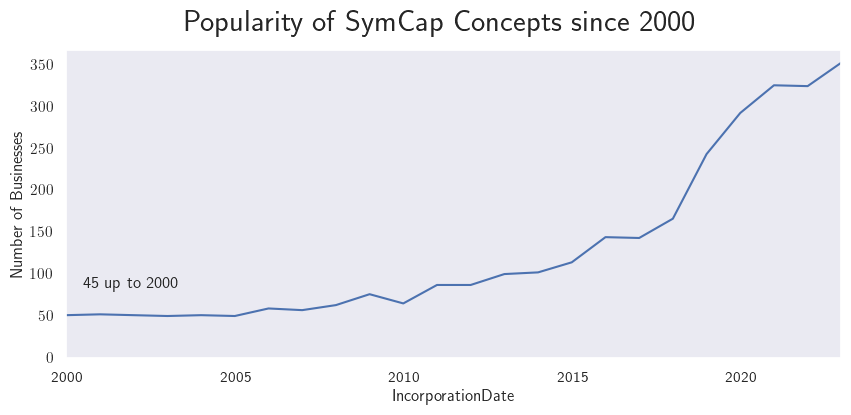

In [137]:
#| label: fig-1
#| fig-cap: General overview of Popularity of SymCap Concepts since 2020. Using a count of keywords in business names and resampling by year. Note that we count by year end on July, as that is where our data cuts off.

fig, ax = plt.subplots(figsize=(10,4))

rrg_all = retail.set_index('IncorporationDate')\
    .sort_index().loc["7-2000":"7-2023"].reset_index()

before2000 = retail.set_index('IncorporationDate')\
    .sort_index().loc[:"7-2000"]['retail_type'].count()
ax = (before2000 +
rrg_all[['retail_type','IncorporationDate']]\
    .resample('YE', on='IncorporationDate').count()).plot(ax=ax)

ax.set_ylabel('Number of Businesses')
ax.set_ylim(0)
ax.text(30.5, before2000 + 38, f'{before2000} up to 2000')
plt.suptitle('Popularity of SymCap Concepts since 2000', 
             fontweight='bold', fontsize=22)
plt.legend().set_visible(False)
plt.show()

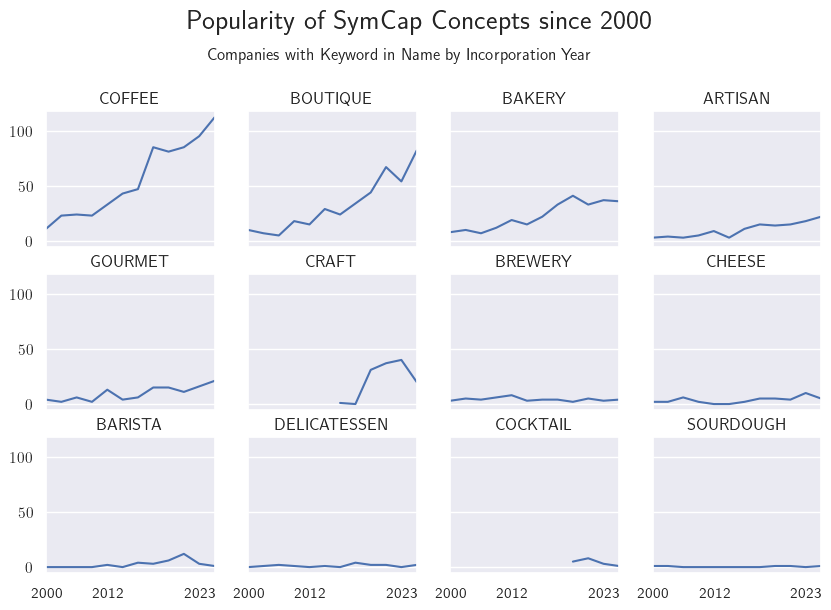

In [138]:
#| label: fig-2
#| fig-cap: Popularity of SymCap Concepts, based on the count of keywords in business names and resampling by year.

_, axs = plt.subplots(3,4, sharey=True, sharex=True)
axs = axs.flatten()

for i, rtype in enumerate(rrg_all.retail_type\
                          .value_counts().index.tolist()):
    
    rrg_all[['retail_type','IncorporationDate']]\
        .query('@rtype in retail_type')\
            .resample('YE', on='IncorporationDate').count()\
                .plot(ax=axs[i], legend=False)
    axs[i].set_title(rtype)
    axs[i].set_xlabel('')
    axs[i].set_xticklabels(['2000', '', '2012','', '', '2023', '']) 
    axs[i].grid(axis='y')

plt.suptitle('Popularity of SymCap Concepts since 2000', 
             fontweight='bold', fontsize=20, y=1.05)

plt.text(13, 460, 'Companies with Keyword in Name by Incorporation Year')
plt.show()

In [ ]:
# A couple of notable statistics:
print(f"""While up to 2000 there were {
    retail.set_index('IncorporationDate')\
        .sort_index().loc[:"7-2000"]['retail_type'].count()
    } SymCap Retail businesses, since then a total of {
        retail.set_index('IncorporationDate')\
            .sort_index().loc["7-2000":]['retail_type'].count()
    } opened.""")

print(f"This is an increase of x {(retail\
            .set_index('IncorporationDate')\
            .sort_index()\
            .loc["7-2000":]['retail_type']\
            .count() /\
                retail.set_index('IncorporationDate')\
                .sort_index().loc[:"7-2000"]['retail_type']\
                        .count()).astype(int)} times.")

print(f"Number of stores that opened since 2021: {retail\
        .set_index('IncorporationDate')\
        .sort_index().loc["7-2021":]['retail_type'].count()
        }.")

### 3.2 Income in London

The income data provides an overview of how earnings have changed in London boroughs from 2010 to 2022. @fig-3 shows that the mean income in London over this period steadily increases. By 2022, the mean income stands at around £60,000 and the median income at around £36,000. We clearly see a divergence between the mean and median. This indicates an increasing skew, or in other words, a fattening tail of high incomes. 

Focussing on the percentage change in income since 2018, we also see a large gap between boroughs. In @fig-4 and @tbl-1 we can see Central London boroughs such as Kensington and Chelsea, Westminster, and the City of London have experienced the most significant increases in income. On the other hand, outer boroughs such as Bexley, Newham, and Barking and Dagenham experienced the smallest increases, further highlighting economic disparities within the city.

In [18]:
# Inner london is used to create a bounding box
london_dd_inner = london_demand_density[
    london_demand_density['Inner/ Outer London'] == 'Inner'
    ].copy()

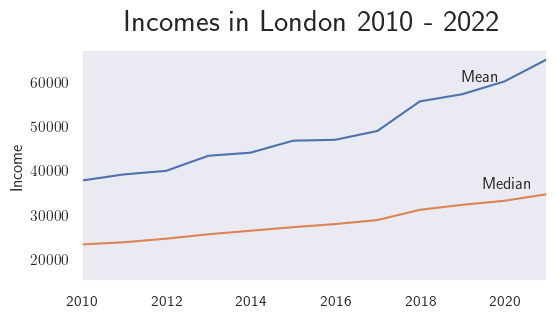

In [54]:
#| label: fig-3
#| fig-cap: The Incomes in London between 2010 and 2022. We can see a widening gap between the mean and median incomes across London. This indicates an increasing skew towards the higher incomes.

mean_and_median = income_df.T.swaplevel('period', 'measure')
ax = mean_and_median.loc['mean'].mean(axis=1)\
    .plot(label='mean', figsize=(6, 3))
mean_and_median.loc['median'].mean(axis=1)\
    .plot(ax=ax, label='median')

ax.set_ylim(bottom=1.5e4)
ax.set_xlabel('')
ax.set_ylabel('Income')
plt.text(49.5, 36000, 'Median')
plt.text(49, 60000, 'Mean')
plt.title('Incomes in London 2010 - 2022', 
          fontweight='bold', fontsize=22, y=1.05)
plt.show()

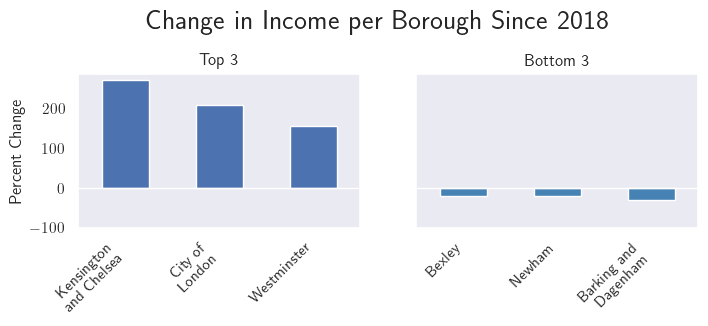

In [178]:
#| label: fig-4
#| fig-cap: The Change in Mean Income per Borough Since 2018. Many boroughs have seen an steady increase in mean and median income. However, there's a stark difference between central London boroughs of Kensington and Chelsea, City of London, and Westminster, and the eastern outer boroughs of Bexley, Newham, and Barking and Dagenham.

_, axs = plt.subplots(1, 2, sharey=True, figsize=(8, 2))

# Calculate top 3 and bottom 3
top3_pct = mean_and_median.loc['mean']\
    .pct_change()['1-1-2018':].sum()\
        .sort_values(ascending=False).iloc[:3] * 100
bottom3_pct = mean_and_median.loc['mean']\
    .pct_change()['1-1-2018':].sum()\
        .sort_values(ascending=False).iloc[-3:]* 100

# Plot top 3
top3_pct.plot.bar(ax=axs[0])
axs[0].set_title('Top 3')
axs[0].axhline(y=0, color='white', linewidth=1)
axs[0].set_xticklabels(['\n'.join(wrap(bor, 12)) 
                        for bor in top3_pct.index], 
                        rotation=45, ha='right')
axs[0].set_xlabel('')


# Plot bottom 3
bottom3_pct.plot.bar(ax=axs[1], color='steelblue')
axs[1].set_title('Bottom 3')
axs[1].axhline(y=0, color='white', linewidth=1)
axs[1].set_xticklabels(['\n'.join(wrap(bor, 12)) 
                        for bor in bottom3_pct.index], 
                        rotation=45, ha='right') 
axs[1].set_xlabel('') 

axs[0].set_ylabel('Percent Change')    
axs[0].set_ylim(-100) 
plt.suptitle('Change in Income per Borough Since 2018', 
             fontweight='bold', fontsize=20, y=1.2)

plt.show()

In [187]:
#| label: tbl-1
#| tbl-cap: Top and Bottom 3 in Mean Income Change
#| tbl-subcap: 
#|   - "Top 3"
#|   - "Bottom 3"
#| layout-ncol: 2

# Top 3
display(top3_pct.to_frame('').round(2))

# Bottom 3
display(bottom3_pct.to_frame('').round(2))

,
Area Name,
Kensington and Chelsea,272.80
City of London,209.07
Westminster,156.10


,
Area Name,
Bexley,-19.69
Newham,-20.90
Barking and Dagenham,-31.01


### 3.3 Traffic calming

There are currently 106 Low-Traffic Neighbourhoods (LTNs) across London, consisting of 492 traffic-calming measures. A specific example from Islington (depicted by @butler2006 in their work on gentrification, shown in @fig-5) situates the geographic context of LTNs, showing their spread along traffic arteries with the detailed annotations that highlight each area. This that how efforts to manage traffic and pollution focusses mainly on cutting through-traffic in residential areas, away from busy high streets. 

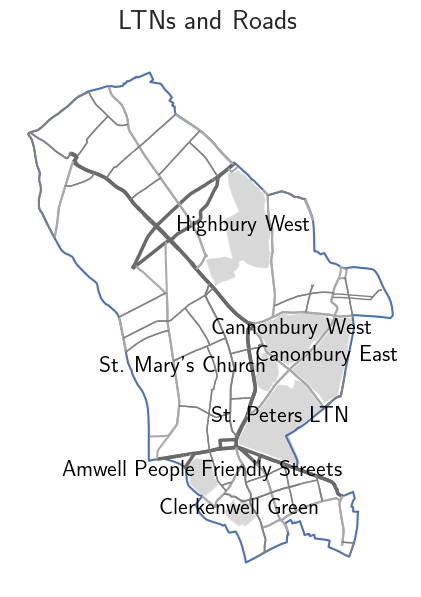

In [246]:
#| label: fig-5
#| fig-cap: An overview of Low-Traffic Neighbourhoods in one Inner London Borough, Islington.

_, ax = plt.subplots(figsize=(6, 7))

Islington = london[london.index == 'Islington']

ltns_islington = ltn[ltn['LGA'] == 'Islington']

# Boundary lines of the borough
Islington.boundary.plot(ax=ax, figsize=(8,4))

# LTNs in Islington
ltns_Islington = ltn[ltn['LGA'] == 'Islington']\
    .plot(ax=ax, alpha=0.3, color='grey')

# Road graph
G = plot_graph_from_polygon(Islington)

# Plot roads
roads = Roads(G)
roads.plot(ax=ax)

ltns_islington['centroid'] = ltn.centroid

# Loop through each polygon and annotate the centroid with the area name
for idx, row in ltns_islington.iterrows():
    align = 'right' if 'Mary' in row['Name'] else 'center'

    ax.text(row['centroid'].x, row['centroid'].y, 
             row['Name'], horizontalalignment=align, 
             fontsize=16, color='black', weight='bold')
    
ax.axis('off')
ax.set_title(r'LTNs and Roads', fontsize=20, weight='bold', y=1.02)
plt.show()

## 4. Analysis

In this section, we will explore and visualise key variables related to demand density, *Symbolic Capital* (SymCap) Retail, and traffic calming measures in London. This analysis is closely tied to our three research questions, examining how urban design interventions like Low-Traffic Neighbourhoods (LTNs) influence retail distribution and neighbourhood transformation.

We begin by addressing research question 3, assessing demand density in more detail to understand how areas with higher demand density attract SymCap Retail businesses (see [3](#Q-3)). This will highlight how demand density might play a more significant role in retail distribution compared to urban design interventions.

Next, we tackle research question [2](#Q-2) by examining income disparities across London and analysing how these economic factors, in combination with LTNs, influence retail clustering patterns. This leads into section 4.3, where we focus on research question [1](#Q-1), exploring how LTNs reshape retail landscapes and support businesses that thrive in pedestrian-friendly environments.

In section 4.4, we further test research questions 1 and 2 by experimenting with graph data science techniques to explore the proximity of SymCap Retail to LTNs. Finally, in section 4.5, we return to our alternative hypothesis and present a Voronoi plot to illustrate the catchment areas of each retail store, offering additional insights into the relationship between demand density and SymCap Retail distribution.

These sections will together form a comprehensive investigation into the interaction of demand density, socio-economic factors, and urban planning in shaping the retail landscape across London. 


### 4.1 Demand Density Insights

Demand density combines population density and income levels to estimate the concentration of potential consumers in a geographic area. It is a key measure of market potential and is often used in retail studies to predict the economic activity and attractiveness of a location. In @fig-6, we visualise changes across London boroughs using demand density data from 2018 to 2022. The row of plots shows the percent change in demand density over the years, highlighting the dynamic economic landscape of the city. For instance, affluent boroughs like Kensington and Chelsea, Richmond upon Thames, and Westminster saw a significant rise in demand density, driven by higher income levels and an underlying stability in terms of population. During the pandemic the City of London witnessed a decline in demand density, which picked up again soon after. In contrast, outer boroughs such as Barking and Dagenham are experiencing a continued decline, illustrating regional economic disparities as can been seen in @tbl-pct-change. 


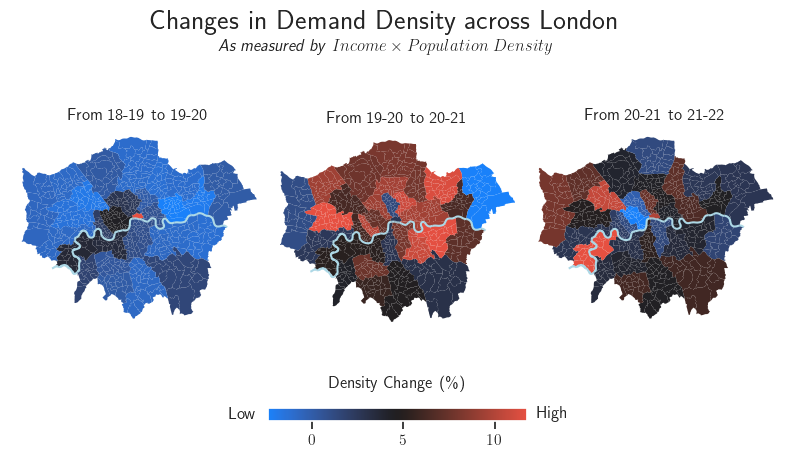

In [19]:
#| label: fig-6
#| fig-cap: Changes in Demand Density across London. Notably, during the pandemic density briefly fell in the City of London as well as the Inner borough of Camden, which notably stands out in blue. However, both quickly recovered, showing in bright red from 20-21 to 21-22. After the City, the greatest rise in Demand Density can be seen in West London boroughs such as Kensington and Chelsea and Richmond upon Thames.

# Changes in Demand Density across London
dd_geo = london_demand_density.copy().to_crs(32630)

fig, ax = plt.subplots(1,3, figsize=(10,4))

for i, col in enumerate(['dd_2018-2019',
                         'dd_2020-2021',
                         'dd_2021-2022']):
    dd_geo['demand_change'] = dd_geo[['dd_2017-2018',
                                      'dd_2018-2019',
                                      'dd_2020-2021',
                                      'dd_2021-2022']]\
                                        .T.pct_change().T[col] * 100
    
    dd_geo.plot(column='demand_change', 
                ax=ax[i], linewidth=0, 
                cmap=cc.cm.bkr)
    river.to_crs(32630).plot(ax=ax[i], 
                             color='lightblue')
    ax[i].axis('off')

cbar = ax[1].get_figure().colorbar(ax[1].collections[0], 
                                   location='bottom', 
                                   orientation='horizontal')
cbar.set_label(r"Density Change (\%)", labelpad=15)
cbar.ax.xaxis.set_label_position('top')

ax[1].text(-0.1, 0.5, 'Low', 
           transform=cbar.ax.transAxes, ha='center', 
           va='center', fontsize=12)
ax[1].text(1.1, 0.5, 'High', 
           transform=cbar.ax.transAxes, ha='center', 
           va='center', fontsize=12)

ax[0].set_title(r'From 18-19 to 19-20')
ax[1].set_title(r'From 19-20 to 20-21')
ax[2].set_title(r'From 20-21 to 21-22')

plt.subplots_adjust(top=1.2)

plt.suptitle(r'Changes in Demand Density across London', 
             fontsize=20, weight='bold', y=1.3)

plt.subplots_adjust(wspace=0, top=1.4)

ax[1].text(1.45, 1.4, 
           r'\textit{As measured by }$Income \times Population\ Density$', 
        fontsize=12, ha='center', va='center', 
        transform=ax[0].transAxes)

plt.show()

In [399]:
#| label: tbl-pct-change
#| tbl-cap: Percent Demand Change for Top and Bottom Boroughs
#| tbl-subcap:
#| - Top 3
#| - Bottom 3
#| layout-ncol: 2

# Calculate total demand change
dd_geo['demand_pct'] = dd_geo[['dd_2017-2018',
                                'dd_2018-2019',
                                'dd_2020-2021',
                                'dd_2021-2022']].T\
                                    .pct_change().T\
                                        .sum(axis=1) * 100

# Percent Change for Top and Bottom Boroughs
top3 = dd_geo.groupby('DISTRICT')['demand_pct']\
    .mean().sort_values(ascending=False)\
        .to_frame().iloc[:3].round(2)

top3 = top3.rename(
    index={'City and County of the City of London': "City of London"})

top3.index.name = 'Borough'

bottom3 = dd_geo.groupby('DISTRICT')['demand_pct']\
    .mean().sort_values(ascending=False).to_frame().iloc[-3:].round(2)

bottom3.index.name = 'Borough'

display(top3)
display(bottom3)

,demand_pct
Borough,
City of London,104.08
Kensington and Chelsea,48.02
Richmond upon Thames,47.00


,demand_pct
Borough,
Hounslow,1.85
Newham,0.23
Barking and Dagenham,-1.67


### 4.2 Income and Retail Relationships

Income distribution across London exhibits a significant disparity between boroughs, with central areas experiencing the most notable income growth. As seen in @fig-7, the City of London stands out as an outlier, with particularly high income levels. This inequality apprears strongly correlated with the distribution of SymCap Retail. Our analysis indicates that boroughs with rising income levels, such as Kensington and Chelsea, tend to host a greater number of SymCap Retail, such as artisanal goods like sourdough bakeries and craft breweries. 

This finding aligns with the *symbolic capital* framework discussed by @carpio2024, where businesses rich in symbolic capital not only mirror but also drive the social and cultural transformation of neighborhoods. This also resonates with the works of sociologists such as Pierre Bourdieu and Jean Baudrillard. Baudrillard, in particular, wrote extensively on the role of semiotics in modern consumerism, focusing on how brands and corporate identity shape consumer relationships. His theories on the symbolic nature of consumption connect well to the current rise of businesses driven by social marketing, where brand identity and lifestyle alignment become crucial.

Empirical studies confirm that urban design interventions like traffic calming measures can reshape the retail landscape by attracting businesses that flourish in pedestrian-friendly environments [@aldred2021]. Meanwhile, SymCap Retail businesses such as artisanal bakeries, craft breweries and niche boutiques, often act as indicators of gentrification. @Barajas2017 similarly emphasises how the emergence of certain high-status businesses can trigger neighborhood transformation, signaling broader socio-economic changes.

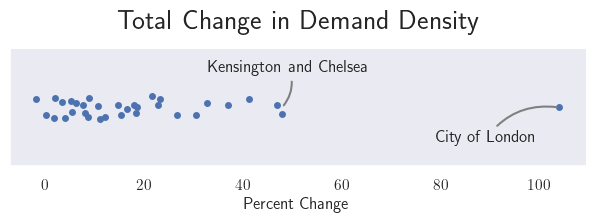

In [222]:
#| label: fig-7
#| fig-cap: Total Change in Demand Density. There is a large gap between the borough with biggest increase in demand density and the rest. We can see that City of London is an outlier. Excluding the City, we see that Kensington and Chelsea leads with Richmond upon Thames closely behind.

catplot = dd_geo\
    .groupby('DISTRICT')['demand_pct']\
    .mean().sort_values(ascending=False).to_frame()

g = sns.catplot(data=catplot, x='demand_pct', 
                height=2, aspect=3)


# Manual annotations
x = catplot.loc['City and County of the City of London', 
                'demand_pct']

g.ax.annotate('City of London', 
            xy=(x, 0), 
            xytext=(x - 25, 0.3),  # Move the text away from the point
            textcoords='data',
            arrowprops=dict(
                arrowstyle="-", 
                connectionstyle="arc3,rad=-.3",  # Makes the line curved
                color='gray',
                lw=1.5 )
                )

x = catplot.loc['Kensington and Chelsea', 'demand_pct']
g.ax.annotate('Kensington and Chelsea', 
            xy=(x, 0), 
            xytext=(x - 15, -0.3),  # Move the text away from the point
            textcoords='data',
            arrowprops=dict(
                arrowstyle="-", 
                connectionstyle="arc3,rad=-.3",  # Makes the line curved
                color='gray',
                lw=1.5 )
                )

g.ax.set_title('Total Change in Demand Density', 
               fontsize=20, fontweight='bold' , y=1.1)

g.ax.set_xlabel('Percent Change')
plt.show()

### 4.3 Low-Traffic Neighbourhoods and Retail Clustering

In this section, we provide a detailed analysis of the interactions between Low-Traffic Neighbourhoods (LTNs) and Retail Clustering. LTNs are designed to reduce vehicular traffic and create more pedestrian-friendly environments. Our analysis explores how these areas intersect with SymCap Retail. @fig-8 illustrates the concentration of LTNs in North-East London, particularly within and just north of the City of London. This figure presents an overview of LTNs and traffic calming measures across Inner London, emphasizing the concentration of LTNs in the North-East.

In @fig-9, we analyse the distribution of different types of retail stores in relation to LTNs. This figure shows the spatial relationships between retail clusters and LTNs, highlighting retail concentrations in Central London areas such as Covent Garden and Fitzrovia.

Lastly, @fig-10 uses a kernel density estimation (KDE) heatmap to show the variation in retail cluster density across several types of SymCap Retail. It uses the borough boundaries again as a visual reference to highlight these patterns. This heatmap reveals heavy concentrations of retail clusters in Central London, with Coffee, Bakery, and Artisan retail spreading westward, while Brewery and Barista retail businesses show stronger clustering towards the east. 

By overlaying the distribution of SymCap Retail businesses with demand density maps, we observe how retail choices align with areas of economic and socio-symbolic affluence. High-status businesses tend to cluster in dynamic and fast-changing neighborhoods, reinforcing the symbolic capital of these areas and contributing to their exclusivity.

Through this visual exploration of SymCap Retail versus LTNs, we can investigate whether urban design interventions do in effect contribute to neighborhood gentrification by attracting wealthy consumers and businesses. As discussed by @carpio2024, this process is closely tied to the broader dynamics of *symbolic consumption*, where the presence of certain businesses enhances the desirability of an area, leading to cycles of increased property values and further investment.

In [21]:
# Take the boundaries of inner london
x, y, mx, my = london_dd_inner.to_crs(32630).total_bounds
inner_inner = box(x, y, mx, my)

# Clip gdf with the new bounds
london_dd_inner_boundary = london_dd_inner.copy()\
    .to_crs(32630).clip(inner_inner).reset_index()

# Clip borough gdf with new bounds
inner_london_bors = london[london['Inner/ Outer London'] == 'Inner']\
    .reset_index().to_crs(32630).clip(inner_inner)

# Set crs for rare retail
if not retail.crs:
    retail.set_crs(4326)
    
retail.to_crs(32630)

assert all(x.crs == 32630 for x in [traffic_calming, ltn, 
                                    river, dd_geo, retail])

In [23]:
def project_and_intersect(to_map = [traffic_calming, ltn, river, dd_geo, retail]):
    """
    Project maps onto a common projection (EPSG: 32630) and confine to common bounds.  
    """
    project_to_32630 = lambda map: map.to_crs(32630)
    intersect = lambda map: gpd.overlay(map, 
                                        london_dd_inner.to_crs(32630), 
                                        how='intersection', 
                                        keep_geom_type=True)

    maps = [project_to_32630(m) for m in to_map]
    return [intersect(gdf) for gdf in maps]

traffic_calming_intersect, ltn_intersect, river_intersect, \
    london_dd_intersect, rrg_intersect = project_and_intersect()

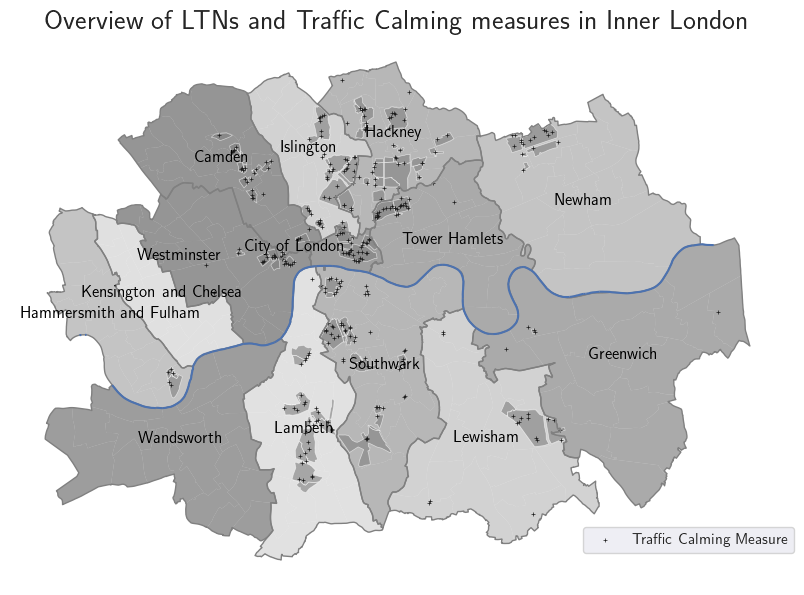

In [24]:
#| label: fig-8
#| fig-cap: Overview of Low-Traffic Neighbourhoods and Traffic Calming measures in Inner London. This highlights the concentration of Low-Traffic Neighbourhoods in North-East London.

# Overview of LTNs and Traffic Calming measures in Inner London
fig, ax = plt.subplots(figsize=(10,8))
london_dd_inner_boundary.plot(ax=ax, column='Area name', linewidth=0, 
                              cmap='cet_cyclic_grey_15_85_c0_s25', 
                              alpha=0.5) 

ltn_intersect.plot(ax=ax, alpha=0.6, color='grey', 
                   linewidth=0.5, edgecolor='white')

traffic_calming_intersect.plot(color='k', ax=ax, 
                               marker='+', markersize=8, 
                               linewidth=0.5, 
                               label='Traffic Calming Measure')

# borough boundary
inner_london_bors.boundary.plot(ax=ax, linewidth=1, edgecolor='grey')

river_intersect.plot(ax=ax)

inner_london_bors['centroid'] = inner_london_bors.centroid

# Loop through each polygon and annotate the centroid with the area name
for idx, row in inner_london_bors.iterrows():
    align = 'right' if ('City' in row['name']) or ('Westminster' in row['name']) else 'center'
    plt.text(row['centroid'].x, row['centroid'].y, 
             row['name'], horizontalalignment=align, 
             fontsize=12, color='black', weight='heavy')

plt.legend(bbox_to_anchor=(0.73, 0.12), loc='upper left')
plt.title('Overview of LTNs and Traffic Calming measures in Inner London', 
          y=1, fontsize=20, weight='bold')
# plt.tight_layout()
ax.axis('off')
plt.show()

In [70]:
assert all(x.crs == 32630 for x in [
    traffic_calming_intersect, ltn_intersect, london_dd_intersect, london_dd_inner_boundary
    ])

In [25]:
# Load road network graph
G = plot_graph_from_polygon(london_dd_inner_boundary, outline=True)

# Load roads
roads = Roads(G)

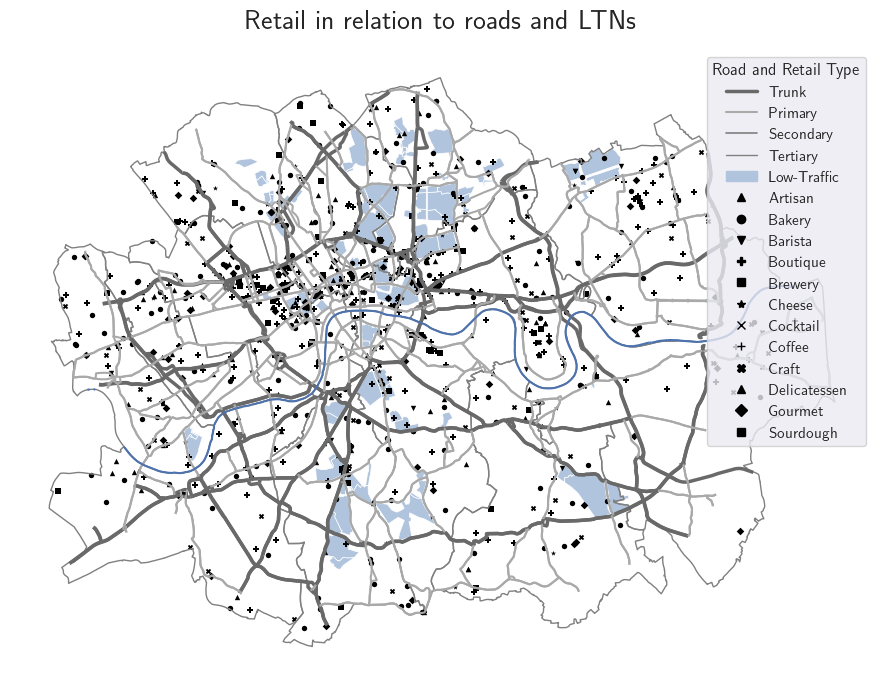

In [33]:
#| label: fig-9
#| fig-cap: Retail in relation to roads and LTNs. We see clear clusters of retail in Central London areas such as Covent Garden and Fitzrovia.

# Retail in relation to roads and LTNs
_, ax = plt.subplots(figsize=(9,7))

inner_london_bors.boundary.plot(ax=ax, linewidth=1, edgecolor='grey')

# Plot roads
_, custom_lines = roads.plot(ax)

# Plot LTNs on the same ax
ltn_intersect.plot(ax=ax, color='lightsteelblue', 
                   markersize=1, linewidth=0.5, 
                   edgecolor='white') 
custom_lines.append(plt.Rectangle((0, 0.2), 1, 2, 
                                  color='lightsteelblue', 
                                  label='Low-Traffic'))

# Plot river
river_intersect.plot(ax=ax)

# Plot retail
categories = rrg_intersect['retail_type'].unique()
markers = ['+','o', 's', '^', 'v', 'D', 'X', 'P', '*', '^', 's', 'x']

marker_map = {category: markers[i] 
              for i, category in enumerate(categories)}

for category, group in rrg_intersect\
    .groupby('retail_type', observed=True):
    group.plot(ax=ax, color='black', 
               marker=marker_map[category], lw=0, 
               markersize=15, label=category)
    custom_lines.append(plt.Line2D([0], [0], color='black', 
                                   marker=marker_map[category], lw=0, 
                                   markersize=6, 
                                   label=f"{category}".capitalize()))

ax.axis('off')
ax.set_aspect('auto') 
ax.legend(handles=custom_lines, title='Road and Retail Type')
plt.title("Retail in relation to roads and LTNs", 
          fontsize=20, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

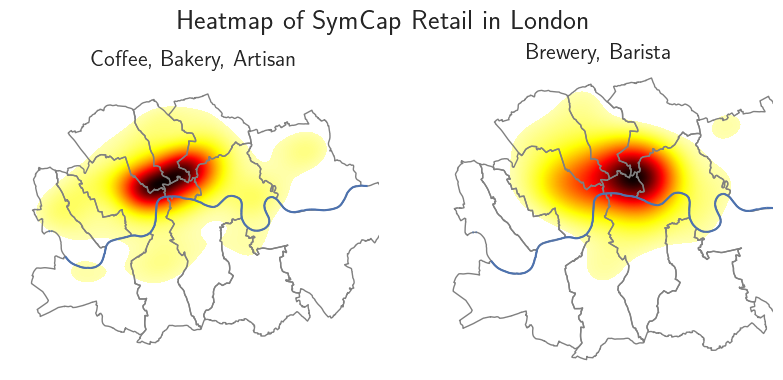

In [333]:
#| label: fig-10
#| fig-cap: A heatmap for several categories of SymCap Retail. We use the borough boundaries as visual reference. Clustering is most apparent north of the river Thames, with Coffee, Bakery, and Artisan showing a spread to West. By contrast, Brewery and Barista seems to concentrate more eastward.

# Heatmap of Retail Clusters
fig, axs = plt.subplots(1, 2, figsize=(10,4))

def plot_heatmap(gdf: gpd.GeoDataFrame, ax: mpl.axes._axes.Axes = ax) -> mpl.axes._axes.Axes:
    
    kde = gaussian_kde([gdf.geometry.x, gdf.geometry.y])

    # Create a grid of points over the area
    xmin, ymin, xmax, ymax = gdf.total_bounds - (2000,2000,-2000,-2000)
    xgrid = np.linspace(xmin, xmax, 1000)
    ygrid = np.linspace(ymin, ymax, 1000)
    xv, yv = np.meshgrid(xgrid, ygrid)

    # Evaluate KDE on the grid
    z = kde(np.vstack([xv.ravel(), yv.ravel()]))
    z = z.reshape(xv.shape)

    # Create a colour scheme 
    cmap = plt.cm.hot_r

    cmap_with_alpha = cmap(np.linspace(0, 1, 256))

    # Add fading effect
    cmap_with_alpha[:20, -1] = 0
    cmap_with_alpha = mpl.colors.ListedColormap(cmap_with_alpha)

    return ax.imshow(z, 
                     extent=[xmin, xmax, ymin, ymax], 
                     origin='lower', cmap=cmap_with_alpha, aspect=1)

hiretail = [['COFFEE', 'BAKERY', 'ARTISAN'], 
            ['BREWERY', 'BARISTA']]

for i, hire in enumerate(hiretail):

    inner_london_bors.boundary.plot(linewidth=1, edgecolor='grey', ax=axs[i])

    river_intersect.plot(ax=axs[i])

    plot_heatmap(rrg_intersect.query('@hire in retail_type'), axs[i])
    
    axs[i].set_title(', '.join([h.capitalize() for h in hire]), y=0.98, fontsize=16, weight='bold')
    axs[i].axis('off')

plt.subplots_adjust(wspace=0.1)
plt.suptitle('Heatmap of Selected Types of Retail across Inner London', y=1.01, fontsize=20, weight='bold')
plt.show()

### 4.4 Proximity Analysis of Retail and LTNs

In this section, we explore the proximity of SymCap Retail businesses to Low-Traffic Neighbourhoods (LTNs) using a graph data science approach. The goal here is to test whether these businesses tend to cluster in pedestrian-friendly environments, as LTNs are designed to reduce traffic and promote walkability. However, instead of conducting a full-scale analysis of all shortest distances between SymCap Retail and LTNs, we employed OSMnx’s graph tools to experiment with such measures. This approach allowed us to explore the potential spatial relationships without the complexity of exhaustive calculations.

Table @tbl-yoy presents our findings, where the difference in SymCap retail presence within strict LTN boundaries does not appear statistically significant. However, when we expand the analysis to include businesses within a 200-metre walking distance from an LTN, we observe a shift. While there are only 212 SymCap stores within LTNs, we find that there are 783 retail stores within 200m from an LTN. We explore this pattern in more detail in section 4.5. This section serves as the final test for research questions 1 and 2, and lays the groundwork for exploring alternative factors such as demand density in more detail (See Question [3](#Q-3)).

First, @fig-11 provides a visual illustration of the dynamic, showing the ease of access to one SymCap retail store within an LTN. By visualising these relationships, we capture the complex interactions between road network design, retail patterns, and socio-economic factors. Although we refrained from measuring the shortest distances across the entire network, these experiments highlight the complexities that urban planners and policymakers must consider when designing walkable environments that support both retail and residential vitality. 


In [35]:
# Calculate which retail is within a LTN
rrg_intersect['within_polygon'] = rrg_intersect.geometry\
    .apply(lambda point: ltn.geometry.apply(lambda poly: point.within(poly)).any())

In [321]:
#| label: tbl-yoy
#| tbl-cap: New Businesses, in Absolute and Pct Yearly Change
#| tbl-subcap:
#| - Within LTNs
#| - NOT within LTNs
#| layout-ncol: 2

display(pd.DataFrame(
    {
        'new': rrg_intersect[rrg_intersect['within_polygon']]\
        .set_index('IncorporationDate').sort_index()\
            .loc["7-2020":"7-2023"]['CompanyName'].resample('YE').count(),
        
        'change': rrg_intersect[rrg_intersect['within_polygon']]\
            .set_index('IncorporationDate').sort_index()\
                .loc["7-2020":"7-2023"]['CompanyName'].resample('YE')\
                    .count().pct_change().fillna(0).round(2)
        }
        ))

display(pd.DataFrame(
    {
        'new': rrg_intersect[~rrg_intersect['within_polygon']]\
        .set_index('IncorporationDate')\
            .sort_index().loc["7-2020":"7-2023"]['CompanyName']\
                .resample('YE').count(),
        
        'change': rrg_intersect[~rrg_intersect['within_polygon']]\
            .set_index('IncorporationDate')\
                .sort_index().loc["7-2020":"7-2023"]['CompanyName']\
                    .resample('YE').count().pct_change().fillna(0).round(2)
    }
    ))

,new,change
IncorporationDate,,
2020-12-31,11,0.00
2021-12-31,28,1.55
2022-12-31,18,-0.36
2023-12-31,20,0.11


,new,change
IncorporationDate,,
2020-12-31,85,0.00
2021-12-31,174,1.05
2022-12-31,169,-0.03
2023-12-31,192,0.14


In [ ]:
# Calculate which retail is within a short distance from a LTN
# We here use Euclidean distance
distances = rrg_intersect.geometry\
    .apply(lambda x: ltn.distance(x).min())

f"There are {(distances < 200).sum()} retail stores within 200m from an LTN."

# For reference
f"There are a total of {rrg_intersect[rrg_intersect['within_polygon']].CompanyName.count()} retail stores within a LTN."

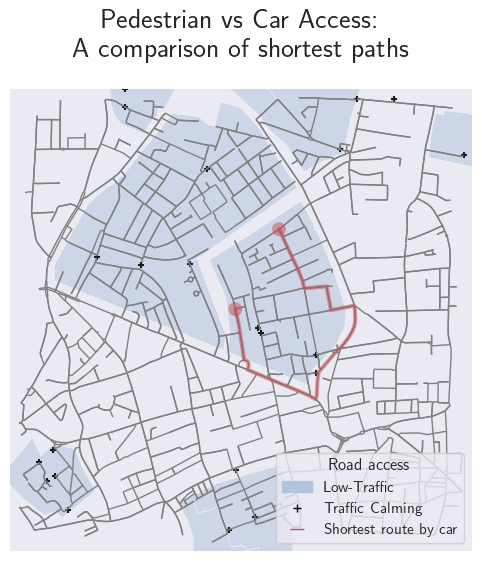

In [396]:
#| label: fig-11
#| fig-cap: To demonstrate the changes in urban composition and access, this plot shows the ease of access for one SymCap retail store located within a Low-Traffic Neighbourhood.

def plot_graph(point):
    # Convert to graph objects
    # Note that the the (latitude, longitude) corresponds to (y, x)
    G_drive = ox.graph_from_point(
        center_point=(point.y, point.x), network_type='drive')

    G_walk = ox.graph_from_point(
        center_point=(point.y, point.x), network_type='walk')

    fig, ax = plt.subplots()

    ltn_intersect.to_crs(epsg=4326)\
        .plot(ax=ax, color='lightsteelblue', 
                markersize=1, linewidth=0.5, 
                edgecolor='white', alpha=0.5) 


    traffic_calming_intersect.to_crs(epsg=4326)\
                            .plot(ax=ax, color='k', 
                            marker='+', markersize=20, 
                            label='Traffic Calming Measure')

    ox.plot_graph(G_drive, ax=ax, node_size=0, 
                edge_linewidth=1, edge_color='gray', show=False) 

    start_node = ox.distance.nearest_nodes(G_drive, point.x, point.y)

    # Calculate shortest route by car
    route = ox.shortest_path(G_drive, start_node[0], 
                            list(G_drive.nodes.keys())[10], weight='length')

    ox.plot_graph_route(G_drive, route, route_color='r', 
                        route_linewidth=3, show=False, 
                        close=False, ax=ax)

    # Custom legend
    custom_lines = [plt.Rectangle((0, 0.2), 1, 2, color='lightsteelblue', 
                                label='Low-Traffic')]

    custom_lines.append(plt.Line2D([0], [0], color='black', marker='+', lw=0, 
                                markersize=6, label="Traffic Calming"))

    custom_lines.append(plt.Line2D([0], [0], color='r', marker='_', lw=0, 
                                markersize=10, label=f"Shortest route by car"))

    ax.legend(handles=custom_lines, title='Road access')

    plt.title(f'Pedestrian vs Car Access: \nA comparison of shortest paths', 
            fontsize=20, fontweight='bold', y=1.05)
    plt.show()

# Take a random retail business inside a LTN
sample = rrg_intersect[rrg_intersect.within_polygon].sample()
point = sample.geometry.to_crs(epsg=4326)
plot_graph(point)

### 4.5 Voronoi Diagram for Retail Catchment Areas

We will here explore the alternate hypothesis that factors as demand density better explain the distribution of SymCap Retail across London. In @fig-12 we apply a Voronoi tessellation, a geometric technique that divides a plane into distinct regions based on proximity to a set of given points. The points represent retail locations such as coffee shops, bakeries, and boutiques. Voronoi tessellation is conceptually related to the K-Nearest Neighbors (KNN) algorithm with K set to 1, meaning that each region, or Voronoi cell, corresponds to the area where any location is closer to a specific retail point than to any other. 

This method helps us understand the catchment areas of SymCap Retail in relation to demand density and LTNs. In areas with dense retail clusters, such as central and West-London, catchment areas are smaller and more concentrated, reflecting the high competition for consumer attention. In contrast, in outer boroughs, retail businesses have larger catchment areas, indicating less competition and lower demand density. We here capture these catchment areas as a geoDataFrame, allowing for further analysis.


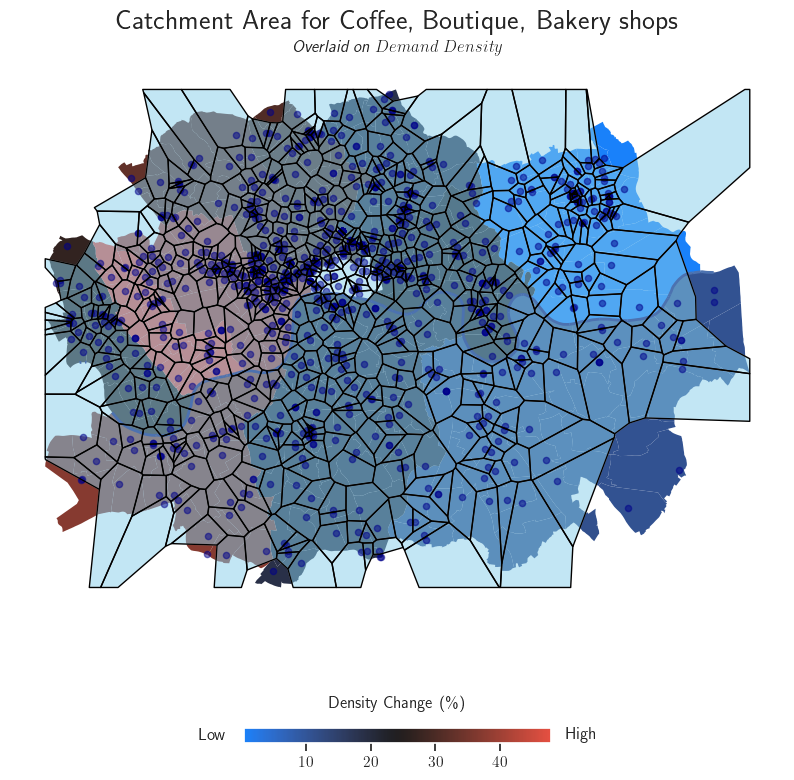

In [42]:
#| label: fig-12
#| fig-cap: The Voronoi Plot shows Catchment Areas, here overlaid on the Total Demand Density. This plot shows clear concentrations in parts of the city that do not have many LTNs but have various other qualities contributing to high quality of life. Note that we have excluded City of London for a more continuous colour scale. We use a subtle shading technique to show cumulative effect of overlapping points. Together the points form blue corridors along certain main roads, showing notable concentrations around certain axes. Conversely, this plot also shows areas of opportunity. 

def plot_voronoi(retail_type=['COFFEE']):
        fig, ax = plt.subplots(figsize=(10,10))

        # Only bakeries
        gdf_voronoi = rrg_intersect.query('@retail_type in retail_type').copy()

        # Plot the demand density layer
        london_dd_intersect['demand_pct'] = london_dd_intersect[
                ['dd_2017-2018_1','dd_2018-2019_1',
                 'dd_2020-2021_1','dd_2021-2022_1']].T.pct_change().T\
                        .sum(axis=1) * 100

        # Remove the City 
        london_dd_intersect_wo_city = london_dd_intersect[
                london_dd_intersect['NAME_1'] != 'Castle Baynard']

        london_dd_intersect_wo_city.plot(column='demand_pct', 
                                         ax=ax, linewidth=0, cmap=cc.cm.bkr)

        # Plot the river intersect, ensuring it's visible
        river_intersect.plot(ax=ax, color='b', linewidth=2)

        # Remove empty points and prepare bakery coordinates
        gdf_voronoi = gdf_voronoi[~gdf_voronoi.geometry.is_empty]
        vor_coords = [(i.coords.xy[0][0], i.coords.xy[1][0]) for i in gdf_voronoi.geometry]

        # Draw the Voronoi diagram
        vor = Voronoi(vor_coords)

        # Convert Voronoi regions to polygons and plot them with Geopandas
        regions, vertices = vor.regions, vor.vertices
        polygons = []
        for region in regions:
                if not -1 in region and len(region) > 0:  # Exclude infinite and empty regions
                        polygon = vertices[region]
                        poly = Polygon(polygon)
                        clipped_poly = poly.intersection(inner_inner)
                        polygons.append(clipped_poly)

        # Create a GeoDataFrame for Voronoi polygons and plot
        voronoi_gdf = gpd.GeoDataFrame(geometry=polygons)

        # Add shading for better visibility
        voronoi_gdf.plot(ax=ax, alpha=0.5, color='skyblue')

        voronoi_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
        
        # Plot the original Voronoi points
        # Using a shading technique
        gdf_voronoi.plot(ax=ax, color='darkblue', 
                          markersize=20, alpha=0.5)        

        # Manually draw colorbar, as above
        cbar = ax.get_figure().colorbar(ax.collections[0], 
                                        location='bottom', 
                                        orientation='horizontal', 
                                        fraction=0.02)
        
        cbar.set_label(r"Density Change (\%)", labelpad=15)
        cbar.ax.xaxis.set_label_position('top')

        # Manually annotate colorbar
        ax.text(-0.1, 0.5, 'Low', transform=cbar.ax.transAxes, 
                ha='center', va='center', fontsize=12)
        
        ax.text(1.1, 0.5, 'High', transform=cbar.ax.transAxes, 
                ha='center', va='center', fontsize=12)

        plt.title(f"Catchment Area for {', '.join([r.capitalize() for r in retail_type])} shops", 
                  fontsize=20, weight='bold', y=1.05)
        
        ax.text(0.5, 1.03, r'\textit{Overlaid on }$Demand \ Density$', 
                fontsize=12, ha='center', va='center', transform=ax.transAxes)
        
        ax.axis('off')
        plt.show()  

plot_voronoi(retail_type=['COFFEE', 'BOUTIQUE', 'BAKERY'])

---


### 5. Conclusion and Evaluation 

This study analysed the spatial dynamics of *Symbolic Capital* (SymCap) Retail in relation to traffic calming measures across London, particularly focusing on Low-Traffic Neighbourhoods (LTNs). The findings reveal notable clustering of SymCap Retail establishments *near* --but not *in*--pedestrian-friendly areas, partially supporting the hypothesis (see Question [1](#Q-1)) that urban design interventions such as LTNs foster favourable conditions for businesses driven by symbolic consumption. 

One key observation is the parallel growth of SymCap Retail and the implementation of traffic calming measures since 2020. With over 2,700 SymCap businesses now operating in London--half of which new since 2021--this market segment is clearly expanding. The increased presence of these kinds  of businesses, such as sourdough bakeries and craft stores, enhances the desirability of these areas, reinforcing the *symbolic capital* framework discussed by @carpio2024. These businesses attract wealthier residents, signalling affluence and contributing to a self-reinforcing cycle of neighbourhood renewal. However, it is important to recognise that this correlation, based on the co-occurrence of events, does not imply any causality. The rise of SymCap Retail and LTNs could be independent trends, driven by broader societal shifts or shared confounding factors. As this was a data science project, the objective was not to definitively establish causality but rather to identify *significant urban trends and patterns*.

The study employed multiple datasets, including business registration data, income statistics, population density, and geospatial data on LTNs. The use of company name keywords to approximate symbolic capital provided useful insights into business distribution. However, future research could improve this methodology by incorporating more sophisticated metrics, such as user ratings from platforms like Foursquare or Google Maps Places API data, as suggested by @carpio2024. Social media engagement, particularly through platforms like Instagram, could further refine the analysis by tracking the social capital associated with businesses and weighting their cultural significance.

A notable limitation of this study is the reliance on live Companies House data, which only accounts for currently active businesses. This approach may underrepresent historical retail dynamics, as dissolved businesses are excluded. Future studies could address this by incorporating historical data on dissolved companies to provide a fuller picture of long-term retail trends.

While the study identified a correlation between LTNs and gentrification-related trends, future research should explore this relationship more deeply. Longitudinal studies that track socio-economic changes over an extended period could offer more concrete evidence of how LTNs influence urban renewal and retail distribution. Such research could help clarify whether LTNs drive gentrification or if other underlying factors play a more significant role.

In conclusion, this project has demonstrated the power of spatial and visual data analysis in uncovering the relationships between urban planning, retail patterns, and socio-economic change. The results offer valuable insights for policymakers and urban planners aiming to promote sustainable and equitable development. By highlighting the influence of symbolic consumption and urban design interventions like LTNs, this study contributes to the ongoing conversation about how modern cities evolve and the factors that shape their economic and social landscapes.

In [45]:
def wordCount():
    import json
    try:
        with open(r'CW2.ipynb') as json_file:
            data = json.load(json_file)
        markdown = []
        for cell in data['cells']:

            if cell['cell_type'] == 'markdown':
                markdown.append(''.join(cell['source']))

        markdown_len = len(' '.join(markdown).split())
        print("The word count of this document is:", markdown_len)
    except OSError:
        print(os.getcwd())
        
wordCount()

The word count of this document is: 3572


### 6. References

:::{#refs}
:::